In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing 
from sklearn import linear_model
from scipy import stats
from scipy.special import boxcox1p
from mpl_toolkits.mplot3d import Axes3D

In [2]:
Swot = pd.read_excel('EXCELforSWOTChangedN.xlsx')
Swot

,On_time,Fares,Entertainment,Food,Market_segments,Partner_agencies,Eco_down,Safety,Overall
0,4,4,4,4,5,4,2,3,5
1,4,4,4,3,5,4,4,4,4
2,4,4,3,4,3,4,4,4,4
3,4,4,4,4,4,2,5,5,4
4,4,3,4,4,4,4,4,4,4
...,...,...,...,...,...,...,...,...,...
118,4,4,3,4,5,5,4,4,4
119,4,4,4,4,3,3,2,4,4
120,4,4,3,3,4,4,4,4,4
121,4,4,3,4,4,4,4,4,4


In [3]:
X = Swot[['On_time','Entertainment','Food']]
Y = Swot[['Overall']]
print(X)

     On_time  Entertainment  Food
0          4              4     4
1          4              4     3
2          4              3     4
3          4              4     4
4          4              4     4
..       ...            ...   ...
118        4              3     4
119        4              4     4
120        4              3     3
121        4              3     4
122        4              4     3

[123 rows x 3 columns]


In [4]:
regr = linear_model.LinearRegression()
model = regr.fit(X, Y)
RM = LinearRegression().fit(X, Y)
print('Intercept:', model.intercept_)
print('Coefficients:', model.coef_)

Intercept: [1.51944492]
Coefficients: [[0.24267285 0.15678996 0.2673995 ]]


In [9]:
X2 = sm.add_constant(X)
est = sm.OLS(Y, X2)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:                Overall   R-squared:                       0.443
Model:                            OLS   Adj. R-squared:                  0.429
Method:                 Least Squares   F-statistic:                     31.52
Date:                Thu, 30 Oct 2025   Prob (F-statistic):           4.55e-15
Time:                        17:39:13   Log-Likelihood:                -84.996
No. Observations:                 123   AIC:                             178.0
Df Residuals:                     119   BIC:                             189.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.5194      0.278      5.459

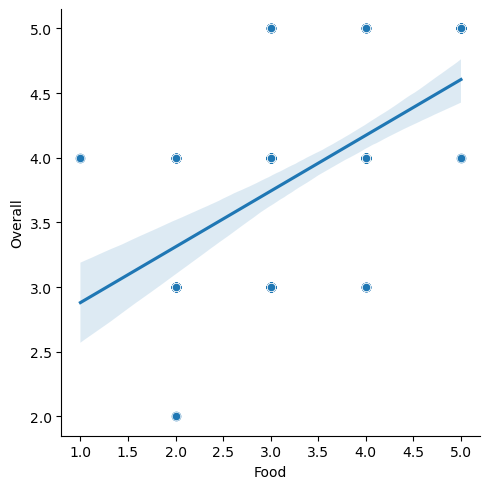

In [11]:
RM.intercept_[0] + RM.coef_[0]
sns.lmplot(x='Food',
               y='Overall',
               data=Swot)

sns.scatterplot(data=Swot, x="Food", y="Overall")
# Show the plot
plt.show()

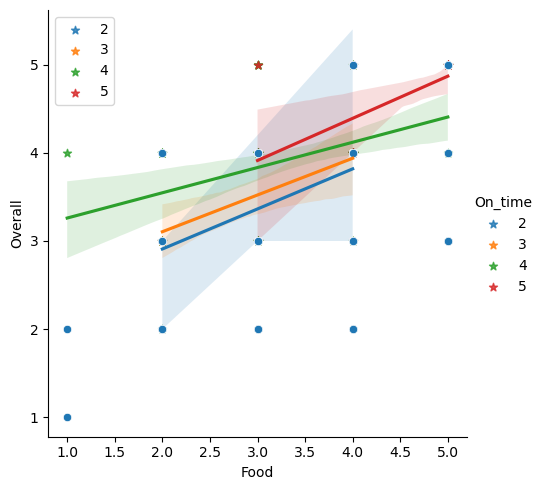

In [16]:
RM.intercept_[0] + RM.coef_[0]
sns.lmplot(x='Food',
               y='Overall',
               hue="On_time",
               markers='*',
               data=Swot)

sns.scatterplot(data=Swot, x="Entertainment", y="Food")
# Show the plot
plt.show()

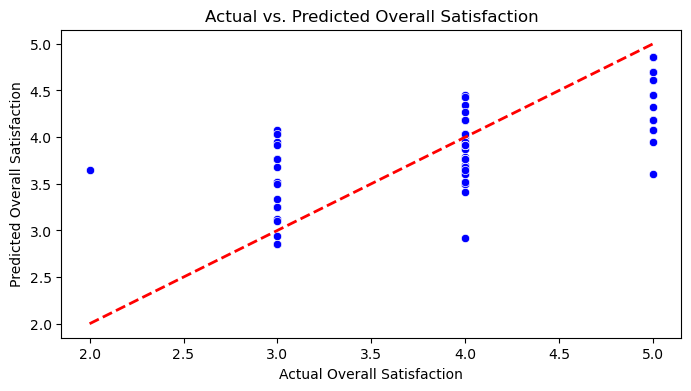

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Fit the model (using your model as reference)
X = Swot[['On_time', 'Entertainment', 'Food']]
X = sm.add_constant(X)  # Adds a constant term to the model
y = Swot['Overall']
model = sm.OLS(y, X).fit()
predictions = model.predict(X)  # Predicted values

# Plot actual vs predicted
plt.figure(figsize=(8, 4))
sns.scatterplot(x=y, y=predictions, marker='o', color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)  # Line of perfect prediction
plt.xlabel("Actual Overall Satisfaction")
plt.ylabel("Predicted Overall Satisfaction")
plt.title("Actual vs. Predicted Overall Satisfaction")
plt.show()


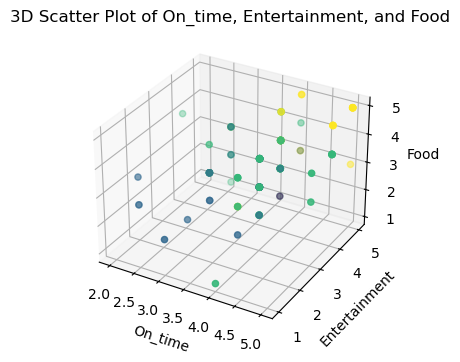

In [20]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Swot['On_time'], Swot['Entertainment'], Swot['Food'], c=y, cmap='viridis', marker='o')

# Set labels
ax.set_xlabel('On_time')
ax.set_ylabel('Entertainment')
ax.set_zlabel('Food')
ax.set_title('3D Scatter Plot of On_time, Entertainment, and Food')
plt.show()


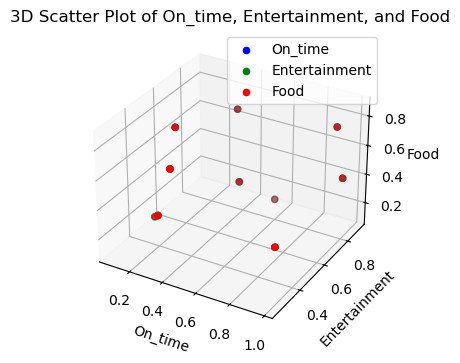

In [22]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Sample data (replace with your actual data)
import pandas as pd
import numpy as np

# Assuming 'Swot' DataFrame contains 'On_time', 'Entertainment', 'Food'
Swot = pd.DataFrame({
    'On_time': np.random.rand(10),
    'Entertainment': np.random.rand(10),
    'Food': np.random.rand(10)
})

# Create 3D plot
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(111, projection='3d')

# Plot each variable with a different color
ax.scatter(Swot['On_time'], Swot['Entertainment'], Swot['Food'], color='blue', label='On_time')
ax.scatter(Swot['On_time'], Swot['Entertainment'], Swot['Food'], color='green', label='Entertainment')
ax.scatter(Swot['On_time'], Swot['Entertainment'], Swot['Food'], color='red', label='Food')

# Set labels and legend
ax.set_xlabel('On_time')
ax.set_ylabel('Entertainment')
ax.set_zlabel('Food')
ax.set_title('3D Scatter Plot of On_time, Entertainment, and Food')
ax.legend(loc='best')

plt.show()
